# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

In [26]:
# Loading the data
import pandas as pd

path=r"C:\Users\smart\OneDrive\Documents\Semester 10\Machine Learning\Lab 4\Lab 4\data_banknote_authentication.csv"
df = pd.read_csv(path, sep=",")

print(df.head())

# Exploring the dataset

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Class distribution (important for classification datasets)
print("\nClass Distribution:")
print(df.iloc[:, -1].value_counts())

# Correlation matrix
print("\nCorrelation Matrix:")
print(df.corr())




   Variance_Wavelet  Skewness_Wavelet  Curtosis_Wavelet  Image_Entropy  Class
0           3.62160            8.6661           -2.8073       -0.44699      0
1           4.54590            8.1674           -2.4586       -1.46210      0
2           3.86600           -2.6383            1.9242        0.10645      0
3           3.45660            9.5228           -4.0112       -3.59440      0
4           0.32924           -4.4552            4.5718       -0.98880      0

Dataset Shape:
(1372, 5)

Data Types:
Variance_Wavelet    float64
Skewness_Wavelet    float64
Curtosis_Wavelet    float64
Image_Entropy       float64
Class                 int64
dtype: object

Missing Values:
Variance_Wavelet    0
Skewness_Wavelet    0
Curtosis_Wavelet    0
Image_Entropy       0
Class               0
dtype: int64

Class Distribution:
Class
0    762
1    610
Name: count, dtype: int64

Correlation Matrix:
                  Variance_Wavelet  Skewness_Wavelet  Curtosis_Wavelet  \
Variance_Wavelet          1.00000

In [27]:
# Train & Split
X = df.drop('Class',axis=1)
y = df['Class']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [28]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier


#model = RandomForestClassifier()
#model.fit(X_train,y_train)
#preds = model.predict(X_test)

# GridSearch
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train DridSearch
grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)

best_rf_model = grid_rf.best_estimator_
y_rf_pred = best_rf_model.predict(X_test)


Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


[[234   4]
 [  0 174]]


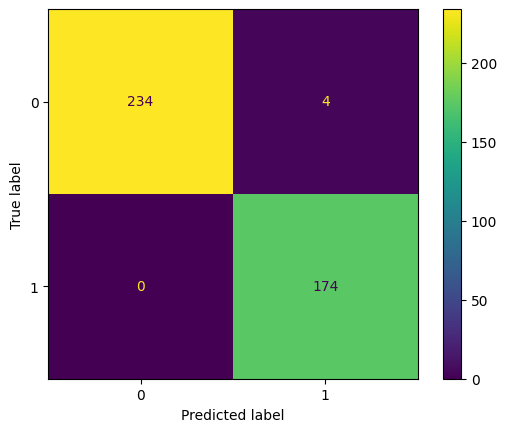

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       238
           1       0.98      1.00      0.99       174

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



In [29]:
# Evaluation --> Random forest
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Confusion Matrix
print(confusion_matrix(y_test, y_rf_pred))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_rf_model, X_test, y_test)
plt.show()

# Classification Report
print(classification_report(y_test, y_rf_pred))

In [30]:
# Decision Trees
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)
base_pred = model.predict(X_test)

# GridSearch
from sklearn.model_selection import GridSearchCV

dt_model = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train GridSearch
grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)

best_dt_model = grid_dt.best_estimator_
y_dt_pred = best_dt_model.predict(X_test)

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


[[237   1]
 [  0 174]]


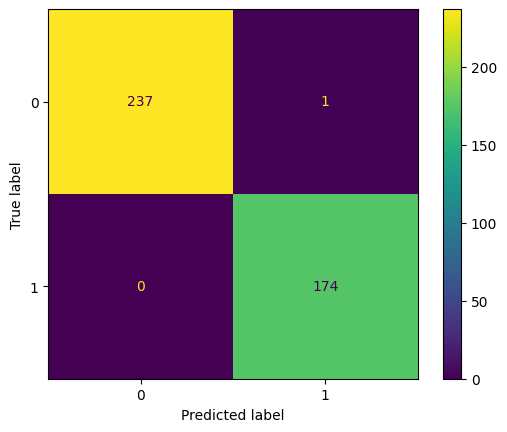

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       238
           1       0.99      1.00      1.00       174

    accuracy                           1.00       412
   macro avg       1.00      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412



In [31]:
# Evaluation --> Decision Tree
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
print(confusion_matrix(y_test, y_dt_pred))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_dt_model, X_test, y_test)
plt.show()

# Classification Report
print(classification_report(y_test, y_dt_pred))

In [32]:
# Comparing the 2 models
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_dt_pred)
rf_accuracy = accuracy_score(y_test, y_rf_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

# Compare models
if rf_accuracy > dt_accuracy:
    print("\nRandom Forest performs better on this dataset.")
elif dt_accuracy > rf_accuracy:
    print("\nDecision Tree performs better on this dataset.")
else:
    print("\nBoth models perform equally on this dataset.")

Decision Tree Accuracy: 0.9975728155339806
Random Forest Accuracy: 0.9902912621359223

Decision Tree performs better on this dataset.
